In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [2]:
using Revise
includet("./base.jl")
import SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.MinimalModelV3

In [3]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Playing around

In [5]:
f = jldopen("./main1.jld2")

fmd = f["metadata"]
# leakxs = LeakageScale.ltox.(fmd.lis)

df = f["df"]
cmats = make_count_matrices(df);
sort(collect(keys(cmats)))

6-element Vector{Int64}:
 -3
 -2
 -1
  1
  2
  3

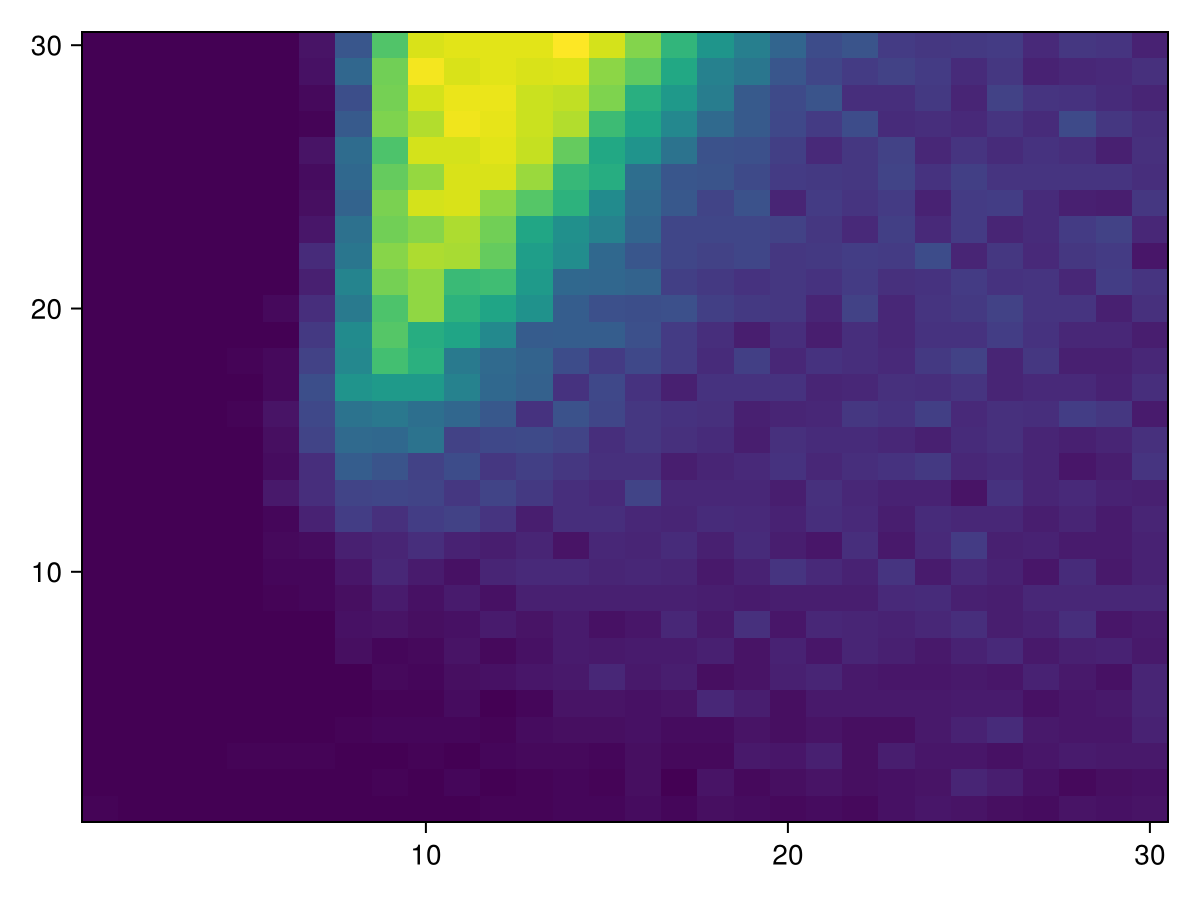

In [7]:
heatmap(cmats[3])

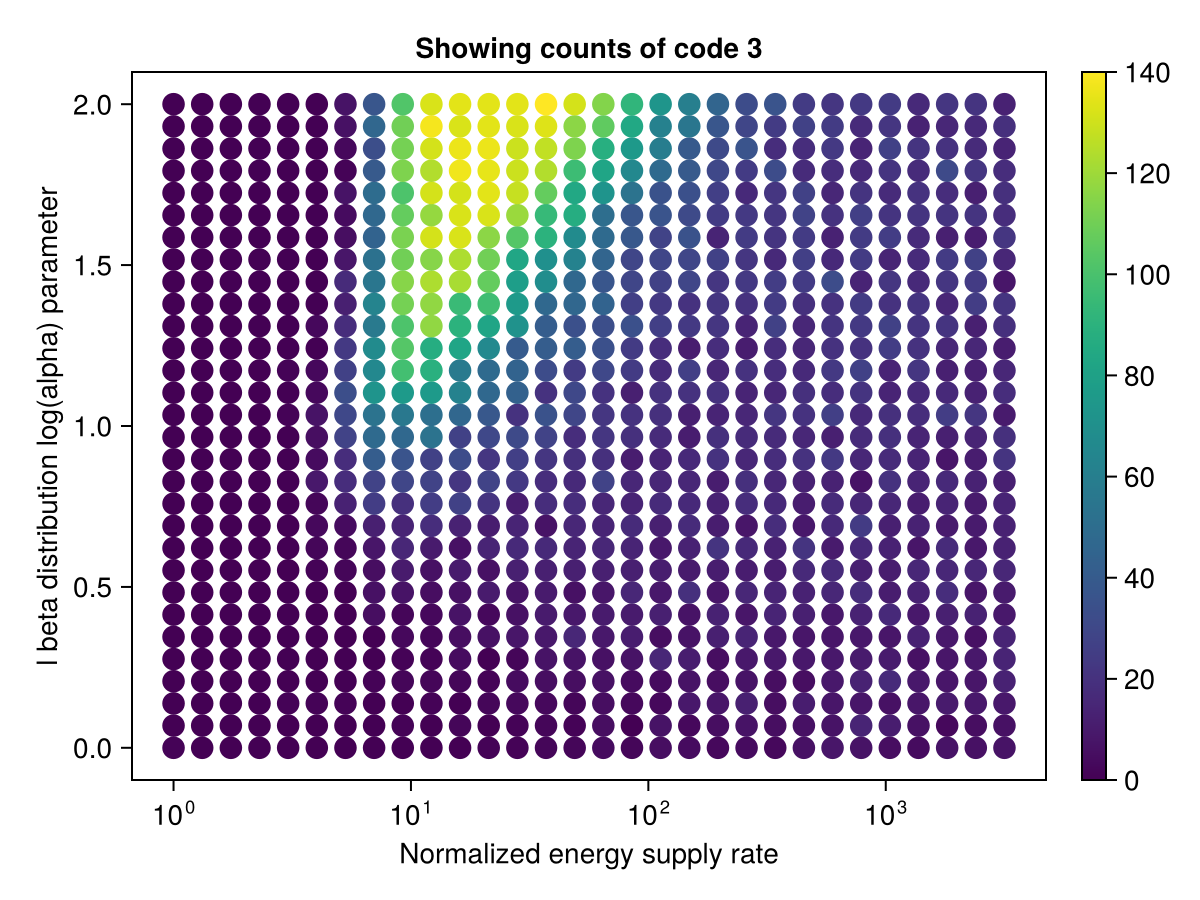

In [18]:
code = 3

fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
    # xticks=log10ticks(-1:4),
    title=(@sprintf "Showing counts of code %d" code),
    xlabel="Normalized energy supply rate",
    ylabel="l beta distribution log(alpha) parameter",
    xgridvisible=false,
    ygridvisible=false,
)

sc = scatter!(ax, [(x, y) for x in fmd.Ks for y in log10.(fmd.lalphas)];
    # marker='.',
    markersize=16,
    color=cmats[code]'[:]
)
Colorbar(fig[1,2], sc)

fig

## Ternary heatmap testing

In [84]:
includet("../../../scripts/ternary_colormap.jl")
includet("../../../scripts/figures_util.jl")
using .TernaryColormaps

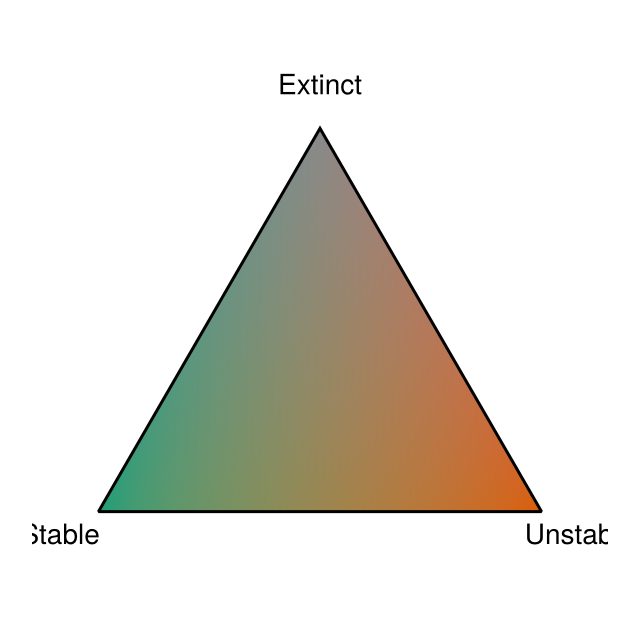

In [91]:
cm = TernaryColormap(PaperColors.extinct(), PaperColors.stable(), PaperColors.unstable())

ternary_legend(cm;
    labels=("Extinct", "Stable", "Unstable"),
    figure=(size=(320, 320),),
    ticks=[],
    # labeloffset=0.1,
)

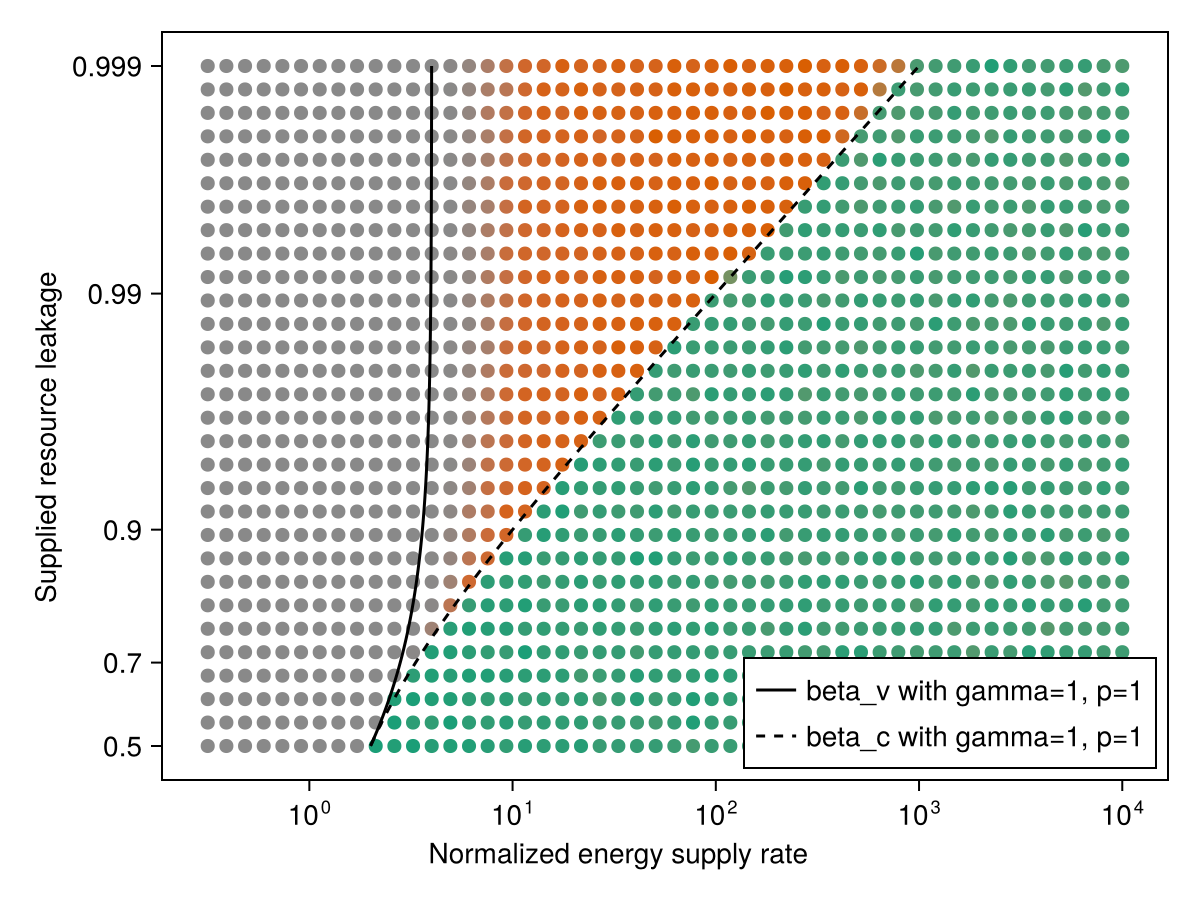

In [97]:
plotline_gpcols = [
    (1., 1., :black),
    # (0.32, 1., (:purple, 0.6)),
]

fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
    # xticks=log10ticks(-1:4),
    # title=(@sprintf "Showing counts of code %d" code),
    xlabel="Normalized energy supply rate            ",
    ylabel="Supplied resource leakage        ",
    xgridvisible=false,
    ygridvisible=false,
)
eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.3g" (1-e)) for e in eps_ticks])
ax.yminorticks = LeakageScale.exminorticks(eps_ticks, 4)

xx = collect(zip(cmats[1], cmats[2], cmats[3]));
yy = map(xx) do t t ./ sum(t) end;
sc = scatter!(ax, [(x, y) for x in fmd.Ks for y in leakxs];
    # marker='.',
    markersize=10,
    color=cm.(yy)'[:]
)
# Colorbar(fig[1,2], sc)

for (gamma, p, color) in plotline_gpcols
    xx = extrema(leakxs)
    leakxs2 = range(xx[1], xx[2], 1000)
    ls2 = LeakageScale.l.(leakxs2)

    extline_Ks = MinimalModelV3.fr3_beta_viable.(ls2, gamma)
    instabline_Ks = MinimalModelV3.fr3_beta_s_qualified.(ls2, gamma, p)

    lines!(ax, extline_Ks, leakxs2;
        color,
        label=(@sprintf "beta_v with gamma=%.3g, p=%.3g" gamma p)
    )
    lines!(ax, instabline_Ks, leakxs2;
        color,
        linestyle=:dash,
        label=(@sprintf "beta_s with gamma=%.3g, p=%.3g" gamma p)
    )
end
axislegend(ax; position=:rb)
# Makie.save("cmat_scatter.pdf", fig)

fig

## Beta dist with fixed beta=1

In [21]:
using Distributions

let
    fig = Figure(size=(800, 600))
    ax = Axis(fig[1, 1]; xlabel="x", ylabel="pdf")
    xlims!(ax, 0, 1)

    sg = SliderGrid(fig[2, 1],
        (label="log10(α)", range=0.0:0.01:2.0, startvalue=log10(5.0), format="{:.2f}"),
    )
    logα = sg.sliders[1].value

    xs = range(0, 1; length=1001)
    ys = lift(la -> pdf.(Beta(10 ^ la, 1), xs), logα)

    lines!(ax, xs, ys; linewidth=2)
    on(ys; update=true) do y
        ymax = maximum(filter(isfinite, y); init=1.0)
        ylims!(ax, 0, 1.05 * ymax)
    end

    Label(fig[0, 1], lift(la -> begin
        a = 10 ^ la
        d = Beta(a, 1)
        mode = a > 1 ? 1.0 : (a < 1 ? 0.0 : NaN)  # Distributions.mode requires α>1 && β>1
        "Beta(α=$(round(a, digits=3)), 1)   mean=$(round(mean(d), digits=4))   mode=$(mode)   sd=$(round(std(d), digits=4))"
    end, logα), tellwidth=false)

    display(GLMakie.Screen(), fig)
end

GLMakie.Screen(...)

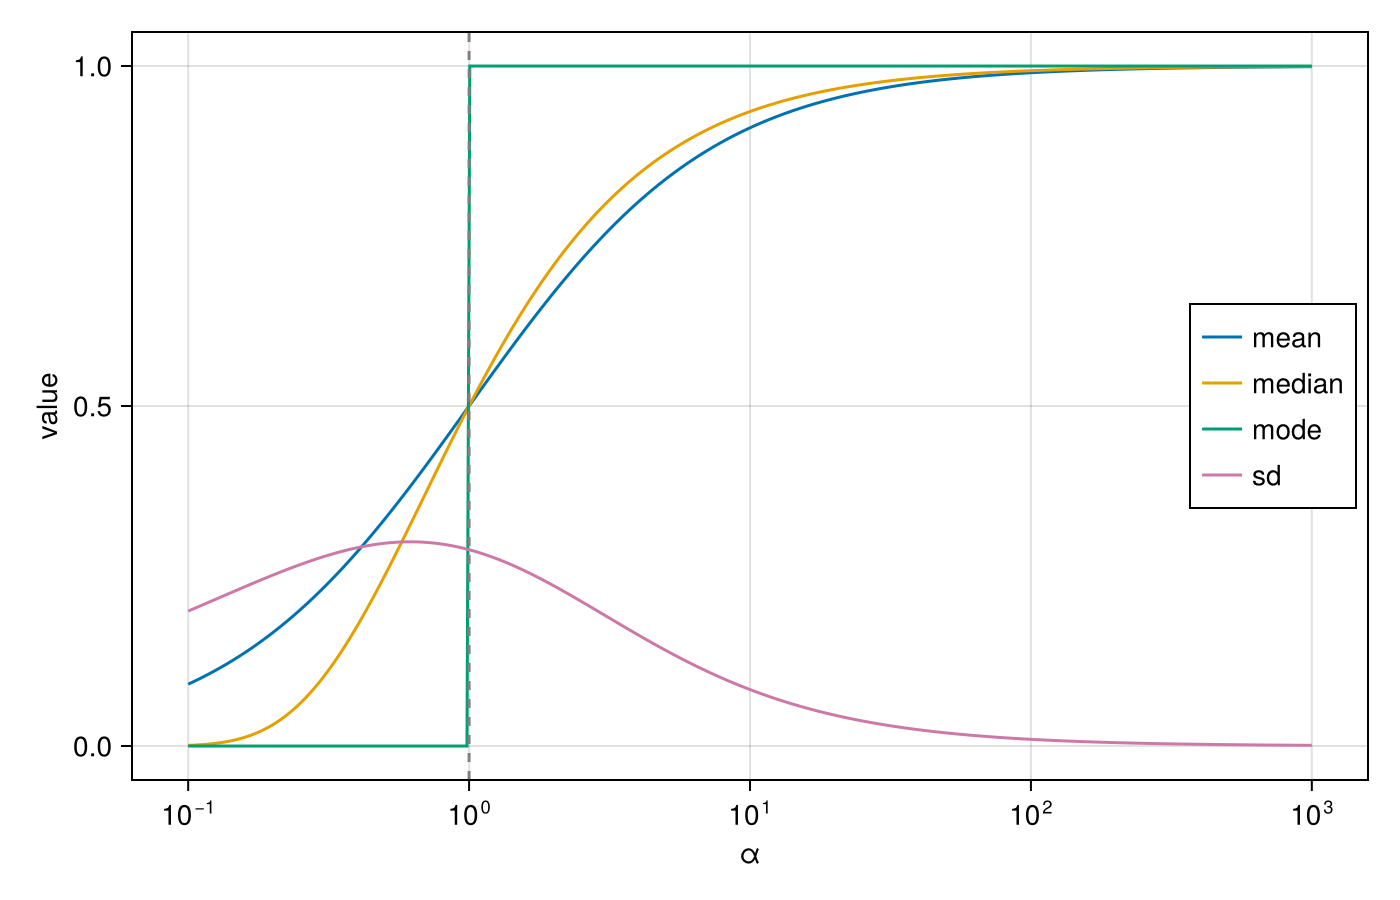

In [26]:
let
    αs = 10 .^ range(-1, 3; length=400)  # 0.01 to 100
    ds = Beta.(αs, 1)

    means = mean.(ds)
    medians = median.(ds)
    modes = [a > 1 ? 1.0 : (a < 1 ? 0.0 : NaN) for a in αs]  # Distributions.mode requires α>1 && β>1
    sds = std.(ds)

    fig = Figure(size=(700, 450))
    ax = Axis(fig[1, 1]; xlabel="α", ylabel="value", xscale=log10)

    lines!(ax, αs, means; label="mean")
    lines!(ax, αs, medians; label="median")
    lines!(ax, αs, modes; label="mode")
    lines!(ax, αs, sds; label="sd")
    vlines!(ax, [1.0]; color=:gray, linestyle=:dash)

    axislegend(ax; position=:rc)
    fig
end